# Ethics in AI lab 6
## Name - Manan Chahal
## Roll No - 23102C0044

Dataset link - https://www.kaggle.com/datasets/stevenpeutz/misinformation-fake-news-text-dataset-79k

In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

true_df = pd.read_csv("data\\DataSet_Misinfo_TRUE.csv")
fake_df = pd.read_csv("data\\DataSet_Misinfo_FAKE.csv")

true_df["label"] = 1
fake_df["label"] = 0



df = pd.concat([true_df, fake_df], axis=0)
df = df.sample(frac=1).reset_index(drop=True)
df = df.dropna(subset=["text"])

print(df.shape)

print(df.head())


(78588, 3)
   Unnamed: 0                                               text  label
0       19130  China on Monday jailed former Tianjin mayor Hu...      1
1       21269  Germany and Europe want to ensure that new U.S...      1
2        6675  One of the greatest institutions in America ri...      0
3       31488  In “Natasha, Pierre  the Great Comet of 1812,”...      1
4       15480  Great press conference with Trump! He makes so...      0


In [3]:
print(df.columns)
print(df.head())

Index(['Unnamed: 0', 'text', 'label'], dtype='str')
   Unnamed: 0                                               text  label
0       19130  China on Monday jailed former Tianjin mayor Hu...      1
1       21269  Germany and Europe want to ensure that new U.S...      1
2        6675  One of the greatest institutions in America ri...      0
3       31488  In “Natasha, Pierre  the Great Comet of 1812,”...      1
4       15480  Great press conference with Trump! He makes so...      0


In [4]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z ]', '', text)

    text = re.sub(r'\s+', ' ', text)

    return text

df["text"] = df["text"].astype(str).apply(clean_text)

In [5]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

In [7]:
model = PassiveAggressiveClassifier(max_iter=50)

model.fit(X_train_vec, y_train)

d:\DOCS\VIT Ebooks\Third Year\Sem 6\Ethics in AI\Lab code\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


,"C C: float, default=1.0Aggressiveness parameter for the passive-agressive algorithm, see [1].For PA-I it is the maximum step size. For PA-II it regularizes thestep size (the smaller `C` the more it regularizes).As a general rule-of-thumb, `C` should be small when the data is noisy.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`~sklearn.linear_model.PassiveAggressiveClassifier.partial_fit` method... versionadded:: 0.19",50
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically set asidea stratified fraction of training data as validation and terminatetraining when validation score is not improving by at least `tol` for`n_iter_no_change` consecutive epochs... versionadded:: 0.20",False
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True... versionadded:: 0.20",0.1
,"n_iter_no_change n_iter_no_change: int, default=5Number of iterations with no improvement to wait before early stopping... versionadded:: 0.20",5
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"loss loss: str, default=""hinge""The loss function to be used:hinge: equivalent to PA-I in the reference paper.squared_hinge: equivalent to PA-II in the reference paper.",'hinge'
,"n_jobs n_jobs: int or None, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [8]:
y_pred = model.predict(X_test_vec)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9540654027229928
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      8729
           1       0.96      0.94      0.95      6989

    accuracy                           0.95     15718
   macro avg       0.95      0.95      0.95     15718
weighted avg       0.95      0.95      0.95     15718



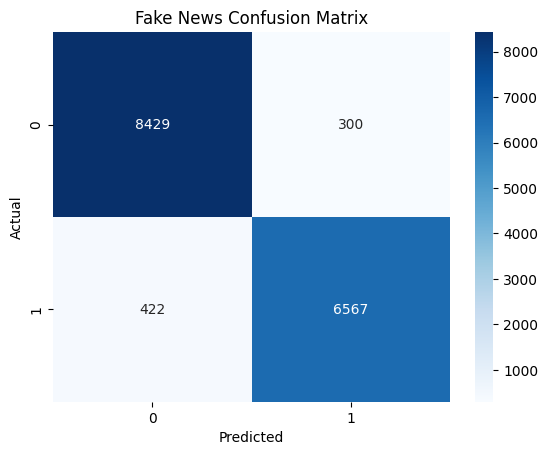

In [10]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fake News Confusion Matrix")

plt.show()

In [11]:
def predict_news(text):

    text = clean_text(text)

    vec = vectorizer.transform([text])

    pred = model.predict(vec)[0]

    if pred == 1:
        return "REAL NEWS"
    else:
        return "FAKE NEWS"

# Peer Review Testing

## Group 1 - Manually tested as False

In [12]:
print(predict_news("""
The Federal Reserve announced new measures on Tuesday aimed at
stabilizing financial markets after recent volatility. Officials
said the policy changes are intended to support economic growth
and ensure long-term financial stability.
"""))

print(predict_news("""
The government announced a new infrastructure program that will
invest billions of dollars into roads, bridges, and public
transportation systems over the next five years. Officials say
the plan will create thousands of jobs.
"""))

print(predict_news("""
Secret documents reveal that a hidden global organization is
controlling world governments and manipulating the media to hide
the truth from citizens. Experts claim the evidence has been
suppressed for years.
"""))

print(predict_news("""
A shocking new report claims that scientists have discovered a
miracle cure that pharmaceutical companies are hiding because it
would eliminate the need for expensive medications.
"""))

print(predict_news("""
Lawmakers debated a new healthcare proposal in Congress on
Wednesday, with supporters arguing the bill will expand coverage
for millions of Americans while critics say it could increase
government spending.
"""))

REAL NEWS
FAKE NEWS
FAKE NEWS
FAKE NEWS
FAKE NEWS


## Group 2 - Manually tested as True

In [31]:
print(predict_news("""
The U.S. Federal Reserve said on Wednesday it would maintain its
current interest rate policy while continuing to monitor inflation
and economic growth. Officials said the decision was intended to
support stable financial conditions.
"""))

print(predict_news("""
The European Union announced new regulations aimed at reducing
carbon emissions from transportation and energy sectors. Leaders
said the plan is part of a broader strategy to meet climate
targets over the next decade.
"""))

print(predict_news("""
The government unveiled a new infrastructure investment program
that will allocate billions of dollars toward modernizing roads,
bridges, and rail networks. Officials say the project is expected
to create thousands of jobs nationwide.
"""))

print(predict_news("""
Lawmakers in Congress debated a new healthcare bill on Tuesday,
with supporters saying it will expand coverage while critics
warned it could increase federal spending over time at a cost told reuters.
"""))

print(predict_news("""
Scientists at a major research university announced a breakthrough
in battery technology that could significantly improve energy
storage for electric vehicles and renewable power systems.
"""))

REAL NEWS
REAL NEWS
FAKE NEWS
REAL NEWS
REAL NEWS


#### Conclusion - we see that the real and fake classification by the model have a fair degree of accuracy even under peer review

In [27]:
feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_fake = coef.argsort()[:20]
top_real = coef.argsort()[-20:]

print("Fake indicators:")
print([feature_names[i] for i in top_fake])

print("\nReal indicators:")
print([feature_names[i] for i in top_real])

Fake indicators:
['didn', 'doesn', 've', 'isn', 'image', 'don', 'october', 'll', 'wfb', 'wasn', 'wouldn', 'snip', 'entire story', 'flickr', 'follow facebook', 'nyp', 'print', 'november', 'loading', 'aren']

Real indicators:
['breitbart texas', 'reporter breitbart', 'said thursday', 'administrations', 'twitter', 'told reuters', 'monday', 'thursday', 'tuesday', 'follow', 'wednesday', 'pic', 'trumps', 'friday', 'said', 'president trumps', 'edt', 'pic twitter', 'president donald', 'com']
